# EDA Multivariado AutoTec

Este notebook tiene como objetivo analizar los factores que influyen en el precio y la depreciación de los vehículos usados publicados en la base de datos de AutoTec.

El análisis considera variables originales como marca, modelo, precio, kilometraje, año, combustible y ciudad. Además, se incluyen variables derivadas para profundizar el análisis, tales como antigüedad del vehículo, uso anual estimado, categoría de precio, rango de kilometraje, tipo de marca y condición ecológica. Además se creó una nueva columna: segmento de depreciación para mejorar el análsis.

La finalidad es comprender cómo estas variables se relacionan con el valor de mercado del vehículo y dejar una base analítica útil para etapas posteriores de modelamiento predictivo.

In [1]:
import os
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, current_date, year as spark_year
from pyspark.sql.functions import avg, count, round as spark_round, desc, lower, trim

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

def formato_chileno(valor):
    try:
        return f"{float(valor):,.0f}".replace(",", ".")
    except:
        return valor

def formato_pesos_eje():
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}".replace(",", "."))
    )

In [2]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = (
    SparkSession.builder
    .appName("EDA_Multivariado_AutoTec")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", "proyecto_bigdata")
    .option("collection", "Contenedor_Autos_Limpio1")
    .load()
)

print("Cantidad de registros cargados:", df.count())

Cantidad de registros cargados: 1685


In [3]:
df_eda = df.select(
    "marca",
    "modelo",
    "precio",
    "kilometraje",
    "year",
    "combustible",
    "ciudad",
    "cat_combustible",
    "uso_anual_estimado",
    "es_ecologico",
    "categoria_precio",
    "rango_kilometraje",
    )



df_eda = df_eda.withColumn(
    "segmento_depreciacion",
    when((col("antiguedad_auto") <= 3) & (col("kilometraje") < 50000), "baja depreciacion")
    .when((col("antiguedad_auto") <= 8) & (col("kilometraje") < 120000), "depreciacion media")
    .otherwise("alta depreciacion")
)

print("Registros disponibles para EDA multivariado:", df_eda.count())
df_eda.show(10, truncate=False)

Registros disponibles para EDA multivariado: 1988
+-----+----------------------------+-------+-----------+----+-----------+--------+---------------+---------------+------------------+------------+----------------+-----------------+----------+---------------------+
|marca|modelo                      |precio |kilometraje|year|combustible|ciudad  |cat_combustible|antiguedad_auto|uso_anual_estimado|es_ecologico|categoria_precio|rango_kilometraje|tipo_marca|segmento_depreciacion|
+-----+----------------------------+-------+-----------+----+-----------+--------+---------------+---------------+------------------+------------+----------------+-----------------+----------+---------------------+
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|27294.0    |2024|bencina    |santiago|0              |2              |13647.0           |0           |Alto            |Bajo             |premium   |baja depreciacion    |
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|11766.0    |2024|bencina    |santiago|0       

## Estadísticas de variables


In [5]:
estadisticas_pd.loc[
    estadisticas_pd["summary"] == "Cantidad de registros",
    "year"
] = "1.988"
estadisticas = df_eda.describe(
    "precio",
    "kilometraje",
    "year",
    "antiguedad_auto",
    "uso_anual_estimado"
)

estadisticas = estadisticas.replace({
    "count": "Cantidad de registros",
    "mean": "Promedio",
    "stddev": "Desviación estándar",
    "min": "Valor mínimo",
    "max": "Valor máximo"
}, subset=["summary"])

estadisticas_pd = estadisticas.toPandas()

for idx in estadisticas_pd.index:
    for col in estadisticas_pd.columns[1:]:

        if col == "year" and estadisticas_pd.loc[idx, "summary"] != "Cantidad de registros":
            estadisticas_pd.loc[idx, col] = int(float(estadisticas_pd.loc[idx, col]))

        else:
            estadisticas_pd.loc[idx, col] = formato_chileno(estadisticas_pd.loc[idx, col])

estadisticas_pd

,summary,precio,kilometraje,year,antiguedad_auto,uso_anual_estimado
0,Cantidad de registros,1.988,1.988,1.988,1.988,1.988
1,Promedio,16.450.599,71.070,2021,5,17.156
2,Desviación estándar,9.970.242,49.937,3,4,10.589
3,Valor mínimo,2.055.000,1.000,1991,0,706
4,Valor máximo,104.990.000,300.000,2026,35,180.000


## Análisis descriptivo de variables principales

La tabla resume las variables más importantes para estudiar el valor de mercado de los vehículos usados. Se observa el comportamiento general del precio, kilometraje, año de fabricación, antigüedad del vehículo y uso anual estimado.

El año de fabricación se mantiene dentro del análisis porque permite comprender la composición temporal de la base y sirve como origen para calcular la antigüedad del vehículo. La antigüedad, en cambio, permite interpretar de manera más directa el efecto del paso del tiempo sobre la depreciación.

La diferencia entre valores mínimos, máximos y promedios muestra que la base contiene vehículos de distintos segmentos, desde automóviles económicos hasta vehículos premium. Esto justifica realizar un análisis multivariado y no evaluar el precio solamente desde una variable.

In [6]:
variables_numericas = [
    "precio",
    "kilometraje",
    "antiguedad_auto",
    "uso_anual_estimado",
    "es_ecologico",
    "cat_combustible"
]

df_corr = df_eda.select(variables_numericas).toPandas()

corr = df_corr.corr().round(2)

corr

,precio,kilometraje,antiguedad_auto,uso_anual_estimado,es_ecologico,cat_combustible
precio,1.00,-0.23,-0.24,0.02,0.15,0.10
kilometraje,-0.23,1.00,0.70,0.35,-0.09,0.19
antiguedad_auto,-0.24,0.70,1.00,-0.25,-0.08,0.01
uso_anual_estimado,0.02,0.35,-0.25,1.00,-0.01,0.21
es_ecologico,0.15,-0.09,-0.08,-0.01,1.00,0.46
cat_combustible,0.10,0.19,0.01,0.21,0.46,1.00


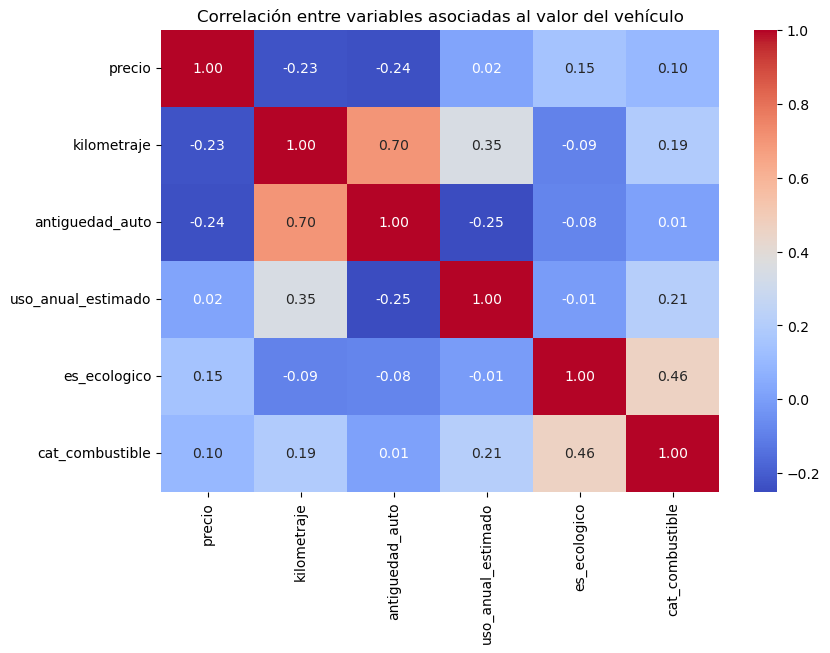

In [7]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlación entre variables asociadas al valor del vehículo")
plt.show()

## Interpretación de la correlación

La matriz de correlación permite observar la relación entre las variables numéricas asociadas al valor de los vehículos.

La variable año de fabricación no se incluye en esta matriz porque fue utilizada para calcular la antigüedad del vehículo. Ambas variables representan el mismo fenómeno temporal desde perspectivas opuestas: mientras el año indica cuándo fue fabricado el automóvil, la antigüedad muestra directamente cuántos años han transcurrido desde entonces.

Por esta razón, para evitar duplicar información dentro de la matriz se utiliza la antigüedad, mientras que el año se mantiene en análisis posteriores para estudiar la evolución de precios según la fecha de fabricación.

Los resultados muestran que el precio disminuye a medida que aumentan el kilometraje y la antigüedad del vehículo, lo que coincide con el comportamiento esperado de la depreciación vehicular.

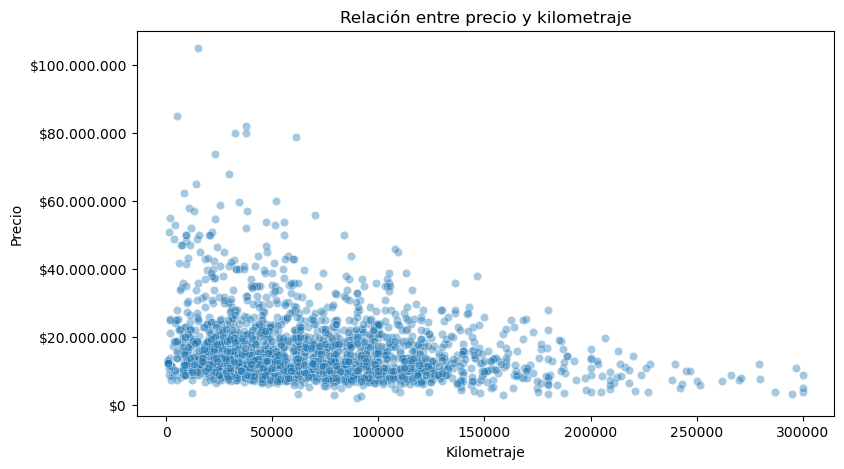

In [8]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_corr,
    x="kilometraje",
    y="precio",
    alpha=0.4
)

plt.title("Relación entre precio y kilometraje")
plt.xlabel("Kilometraje")
plt.ylabel("Precio")
formato_pesos_eje()

plt.show()

## Interpretación de la relación precio y kilometraje

El gráfico muestra una tendencia general de disminución del precio a medida que aumenta el kilometraje del vehículo. Los automóviles con menor uso acumulado se concentran en rangos de precio más altos, mientras que los vehículos con mayor kilometraje presentan valores de mercado menores.

Sin embargo, también se observan algunos vehículos con precios elevados pese a registrar niveles intermedios de kilometraje. Esto indica que el valor del vehículo no depende exclusivamente del uso acumulado, sino también de factores como la marca, el año de fabricación y el equipamiento.

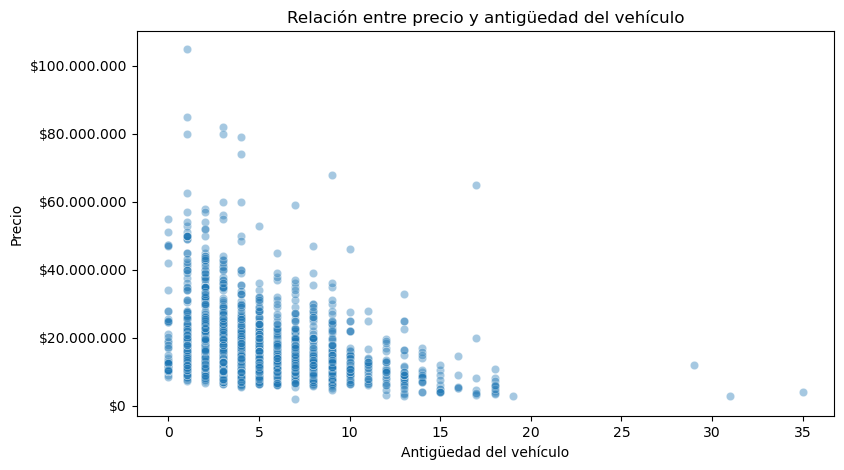

In [9]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_corr,
    x="antiguedad_auto",
    y="precio",
    alpha=0.4
)

plt.title("Relación entre precio y antigüedad del vehículo")
plt.xlabel("Antigüedad del vehículo")
plt.ylabel("Precio")
formato_pesos_eje()

plt.show()

## Relación entre precio y antigüedad del vehículo

El gráfico muestra una tendencia general de disminución del precio a medida que aumenta la antigüedad del vehículo. Los automóviles más recientes se concentran en rangos de precio más altos, mientras que los vehículos con mayor cantidad de años suelen presentar valores de mercado inferiores, lo que es consistente con el proceso natural de depreciación.

Sin embargo, también se observan algunos vehículos con precios elevados a pesar de tener varios años de antigüedad. Esto indica que el valor de un automóvil no depende únicamente del tiempo transcurrido desde su fabricación, sino también de otros factores como la marca, el modelo, el kilometraje, el equipamiento y el tipo de combustible.

En general, la antigüedad aparece como una variable relevante para explicar el comportamiento del precio, aunque su efecto debe analizarse en conjunto con otras características del vehículo.

In [12]:
from pyspark.sql.functions import col
df_year = (
    df_eda.groupBy("year")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio")
    )
    .filter(col("cantidad") >= 3)
    .orderBy("year")
)

df_year_pd = df_year.toPandas()

for columna in ["precio_promedio", "kilometraje_promedio"]:
    df_year_pd[columna] = df_year_pd[columna].apply(formato_chileno)

df_year_pd

,year,cantidad,precio_promedio,kilometraje_promedio
0,2008,10,6.066.000,236.520
1,2009,7,15.420.000,128.105
2,2010,5,7.884.000,186.326
3,2011,11,6.434.545,190.164
4,2012,16,9.642.500,167.176
5,2013,28,11.190.000,130.043
6,2014,25,11.074.400,156.732
7,2015,23,12.153.913,128.506
8,2016,42,13.832.143,109.705
9,2017,91,14.666.813,115.764


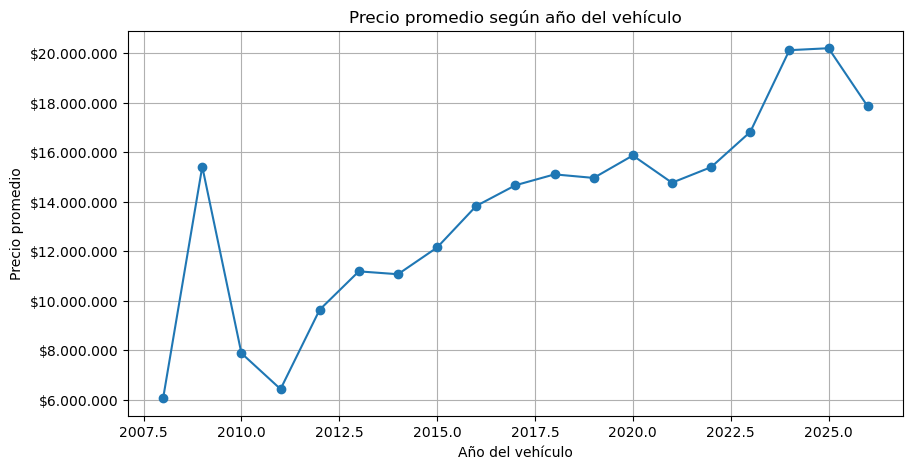

In [13]:
df_year_grafico = df_year.toPandas()

plt.figure(figsize=(10, 5))

plt.plot(
    df_year_grafico["year"],
    df_year_grafico["precio_promedio"],
    marker="o"
)

plt.title("Precio promedio según año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio promedio")
formato_pesos_eje()
plt.grid(True)

plt.show()

## Precio promedio según año del vehículo

El análisis por año permite observar cómo varía el precio promedio según la fecha de fabricación del vehículo. En general, los vehículos más recientes tienden a presentar precios más altos, mientras que los modelos más antiguos suelen mostrar valores menores.

Esta sección justifica el uso de la variable "year", ya que permite comprender la composición temporal de la base y analizar el efecto del año de fabricación sobre el precio. Además, permite complementar la variable "antiguedad_auto", que resume este mismo fenómeno desde la perspectiva del tiempo transcurrido desde la fabricación.

In [14]:
df_marca = (
    df_eda.groupBy("marca")
    .agg(
        count("*").alias("cantidad"),
        spark_round(avg("precio"), 0).alias("precio_promedio"),
        spark_round(avg("kilometraje"), 0).alias("kilometraje_promedio"),
        spark_round(avg("antiguedad_auto"), 0).alias("antiguedad_promedio")
    )
    .filter(col("cantidad") >= 10)
    .orderBy(desc("precio_promedio"))
    .limit(10)
)

marca_pd = df_marca.toPandas()

for c in marca_pd.columns:
    if c != "marca":
        marca_pd[c] = marca_pd[c].apply(formato_chileno)

marca_pd

,marca,cantidad,precio_promedio,kilometraje_promedio,antiguedad_promedio
0,lexus,10,32.471.000,85.743,5
1,bmw,41,31.775.854,75.431,7
2,mercedes,25,30.614.400,89.513,8
3,audi,38,29.957.105,61.728,5
4,ford,174,24.979.799,73.605,5
5,subaru,38,20.130.000,82.175,5
6,toyota,131,19.984.007,74.372,4
7,mazda,48,19.541.458,79.089,6
8,volvo,15,18.732.667,104.674,9
9,jeep,33,17.277.879,94.104,7


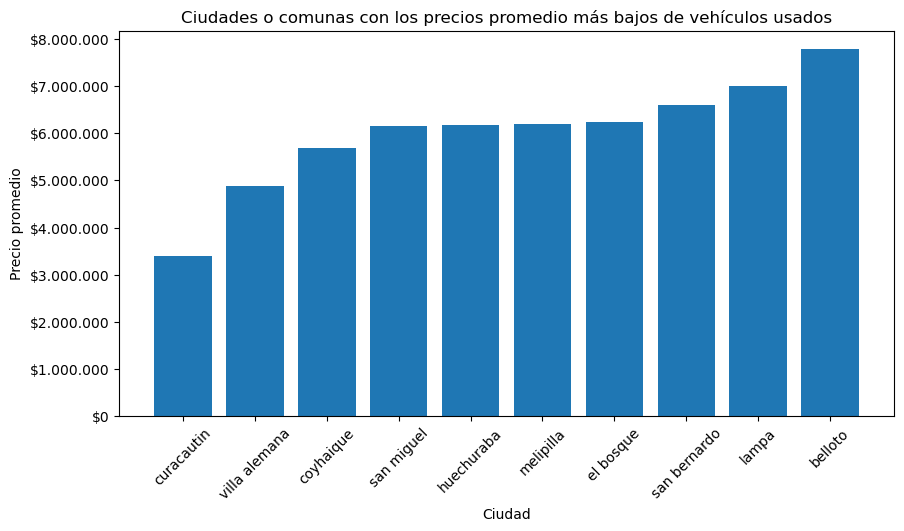

In [15]:
df_ciudad_bajo_precio = (
    df_eda.groupBy("ciudad")
    .agg(
        spark_round(avg("precio"),0).alias("precio_promedio")
    )
    .orderBy("precio_promedio")
    .limit(10)
)
ciudad_grafico = df_ciudad_bajo_precio.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    ciudad_grafico["ciudad"],
    ciudad_grafico["precio_promedio"]
)

plt.title("Ciudades o comunas con los precios promedio más bajos de vehículos usados")
plt.xlabel("Ciudad")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
formato_pesos_eje()

plt.show()

## Interpretación de las ciudades o comunas

El gráfico muestra las ciudades o comunas con los precios promedio más bajos de vehículos usados dentro de la base analizada. Se observan diferencias moderadas entre las distintas ubicaciones, aunque los valores se mantienen dentro de rangos relativamente similares.

Estas variaciones pueden estar relacionadas con la composición de la oferta disponible en cada zona, la presencia de vehículos de distintas categorías y las características particulares de cada mercado local. Además, factores como la antigüedad, el kilometraje y la marca de los vehículos también pueden influir en los promedios observados.

Por esta razón, la ubicación geográfica aporta información complementaria para comprender el comportamiento de los precios, aunque no constituye el principal factor explicativo de las diferencias de valor entre vehículos.

# Conclusión del análisis inicial

El análisis exploratorio permitió identificar patrones relevantes en el comportamiento de los precios de los vehículos usados presentes en la base AutoTec. Los resultados muestran que variables como el año de fabricación, la antigüedad y el kilometraje presentan una relación importante con el valor de mercado de los vehículos.

Asimismo, se observaron diferencias entre grupos de vehículos según su ubicación geográfica y otras características generales de la base de datos. Estos hallazgos entregan una primera comprensión del conjunto de datos y permiten establecer una base sólida para análisis posteriores más avanzados.

En la siguiente etapa se profundizará en el estudio de relaciones entre variables, segmentación de vehículos y detección de anomalías, con el objetivo de comprender de manera más detallada los factores que influyen en la valorización del mercado de vehiculos usados.